# Solving CartPole-v1 with PPO (from scratch)

This notebook demonstrates how to solve the CartPole-v1 environment using a custom implementation of the Proximal Policy Optimization (PPO) algorithm in PyTorch. No external RL libraries are used.

## 1. Install and Import Required Libraries
We will use gymnasium and torch for this implementation.

In [1]:
# Install and import required libraries
import sys
import subprocess

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try:
    import gymnasium as gym
except ImportError:
    install("gymnasium")
    import gymnasium as gym

try:
    import torch
except ImportError:
    install("torch")
    import torch

import numpy as np
import torch.nn as nn
import torch.optim as optim

## 2. Set Up CartPole-v1 Environment
We will initialize the CartPole-v1 environment and display its basic information.

In [2]:
# Set up the CartPole-v1 environment
env = gym.make("CartPole-v1")
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.n
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)


## 3. Implement PPO Agent
We will define the policy and value networks, and the PPO update step.

In [3]:
# Policy and Value Networks
class PolicyNet(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, act_dim)
        )
    def forward(self, x):
        return self.net(x)

class ValueNet(nn.Module):
    def __init__(self, obs_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

## 4. Train PPO Agent
We will train the PPO agent on CartPole-v1.

In [ ]:
# Helper functions for PPO
from torch.distributions.categorical import Categorical
import matplotlib.pyplot as plt
import random

def set_global_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95):
    advantages = []
    gae = 0
    values = values + [0]
    for t in reversed(range(len(rewards))):
        delta = rewards[t] + gamma * values[t+1] * (1 - dones[t]) - values[t]
        gae = delta + gamma * lam * (1 - dones[t]) * gae
        advantages.insert(0, gae)
    return advantages

# TODO: generalize into method that can also render N episodes
def evaluate_policy(policy, env_name="CartPole-v1", n_episodes=20):
    rewards = []
    for ep in range(n_episodes):
        eval_env = gym.make(env_name)
        eval_seed = np.random.randint(0, 1000000)
        obs, info = eval_env.reset(seed=eval_seed)
        done = False
        ep_reward = 0
        while not done:
            obs_t = torch.as_tensor(obs, dtype=torch.float32)
            logits = policy(obs_t)
            dist = Categorical(logits=logits)
            action = dist.probs.argmax().item()
            obs, reward, terminated, truncated, info = eval_env.step(action)
            done = terminated or truncated
            ep_reward += reward
        rewards.append(ep_reward)
        eval_env.close()
    mean_reward = np.mean(rewards)
    return mean_reward, rewards

# Set fixed seed for training
TRAIN_SEED = 42
set_global_seed(TRAIN_SEED)
obs, info = env.reset(seed=TRAIN_SEED)

# PPO Training Loop
policy = PolicyNet(obs_dim, act_dim)
value = ValueNet(obs_dim)
policy_optim = optim.Adam(policy.parameters(), lr=3e-4)
value_optim = optim.Adam(value.parameters(), lr=1e-3)

clip_epsilon = 0.2
minibatch_size = 64
gamma = 0.99
lam = 0.95
episodes_per_epoch = 10  # Number of episodes to run per epoch
eval_interval = 5  # Evaluate every n epochs
eval_episodes = 20  # Number of episodes for evaluation
reward_threshold = 500  # Solved threshold
#max_epochs = 200  # Safety cap

train_rewards = []  # Store mean reward per epoch
solved = False
current_epoch = 0

while not solved:# and current_epoch < max_epochs:
    obs_buf, act_buf, adv_buf, ret_buf, logp_buf = [], [], [], [], []
    val_buf, rew_buf, done_buf = [], [], []
    episode_rewards = []
    episodes_collected = 0
    obs, info = env.reset()
    done = False
    ep_rews = []
    while episodes_collected < episodes_per_epoch:
        obs_t = torch.as_tensor(obs, dtype=torch.float32)
        logits = policy(obs_t)
        dist = Categorical(logits=logits)
        action = dist.sample()
        logp = dist.log_prob(action)
        value_pred = value(obs_t).item()
        next_obs, reward, terminated, truncated, info = env.step(action.item())
        done_flag = terminated or truncated
        obs_buf.append(obs)
        act_buf.append(action.item())
        logp_buf.append(logp.item())
        val_buf.append(value_pred)
        rew_buf.append(reward)
        done_buf.append(done_flag)
        obs = next_obs
        ep_rews.append(reward)
        if done_flag:
            episode_rewards.append(sum(ep_rews))
            obs, info = env.reset()
            ep_rews = []
            episodes_collected += 1
    if ep_rews:
        episode_rewards.append(sum(ep_rews))
    train_rewards.append(np.mean(episode_rewards))
    adv_buf = compute_gae(rew_buf, val_buf, done_buf, gamma, lam)
    ret_buf = (np.array(adv_buf) + np.array(val_buf)).tolist()
    # Convert buffers to tensors
    obs_tensor = torch.as_tensor(np.array(obs_buf), dtype=torch.float32)
    act_tensor = torch.as_tensor(np.array(act_buf), dtype=torch.int64)
    adv_tensor = torch.as_tensor(np.array(adv_buf), dtype=torch.float32)
    ret_tensor = torch.as_tensor(np.array(ret_buf), dtype=torch.float32)
    logp_old_tensor = torch.as_tensor(np.array(logp_buf), dtype=torch.float32)
    # Normalize advantages
    adv_tensor = (adv_tensor - adv_tensor.mean()) / (adv_tensor.std() + 1e-8)
    # PPO update
    num_samples = len(obs_buf)
    for _ in range(10):
        idx = np.random.permutation(num_samples)
        for start in range(0, num_samples, minibatch_size):
            end = start + minibatch_size
            mb_idx = idx[start:end]
            logits = policy(obs_tensor[mb_idx])
            dist = Categorical(logits=logits)
            logp = dist.log_prob(act_tensor[mb_idx])
            ratio = torch.exp(logp - logp_old_tensor[mb_idx])
            surr1 = ratio * adv_tensor[mb_idx]
            surr2 = torch.clamp(ratio, 1 - clip_epsilon, 1 + clip_epsilon) * adv_tensor[mb_idx]
            policy_loss = -torch.min(surr1, surr2).mean()
            value_pred = value(obs_tensor[mb_idx]).squeeze()
            value_loss = ((ret_tensor[mb_idx] - value_pred) ** 2).mean()
            policy_optim.zero_grad()
            policy_loss.backward()
            policy_optim.step()
            value_optim.zero_grad()
            value_loss.backward()
            value_optim.step()
    current_epoch += 1
    print(f"Epoch {current_epoch} complete. Mean train reward: {train_rewards[-1]:.2f}")
    if current_epoch % eval_interval == 0:
        mean_eval_reward, _ = evaluate_policy(policy, env, n_episodes=eval_episodes)
        print(f"Evaluation after {current_epoch} epochs: Mean reward = {mean_eval_reward:.2f}")
        if mean_eval_reward >= reward_threshold:
            print(f"Solved! Mean evaluation reward {mean_eval_reward:.2f} >= {reward_threshold}")
            solved = True

Epoch 1 complete. Mean train reward: 22.00
Epoch 2 complete. Mean train reward: 15.90
Epoch 3 complete. Mean train reward: 18.00
Epoch 4 complete. Mean train reward: 34.60
Epoch 4 complete. Mean train reward: 34.60
Epoch 5 complete. Mean train reward: 55.60
Epoch 5 complete. Mean train reward: 55.60
Evaluation after 5 epochs: Mean reward = 294.70
Evaluation after 5 epochs: Mean reward = 294.70
Epoch 6 complete. Mean train reward: 60.40
Epoch 6 complete. Mean train reward: 60.40
Epoch 7 complete. Mean train reward: 87.40
Epoch 7 complete. Mean train reward: 87.40
Epoch 8 complete. Mean train reward: 98.90
Epoch 8 complete. Mean train reward: 98.90
Epoch 9 complete. Mean train reward: 88.20
Epoch 9 complete. Mean train reward: 88.20
Epoch 10 complete. Mean train reward: 168.20
Epoch 10 complete. Mean train reward: 168.20
Evaluation after 10 epochs: Mean reward = 452.30
Evaluation after 10 epochs: Mean reward = 452.30
Epoch 11 complete. Mean train reward: 143.20
Epoch 11 complete. Mean tr

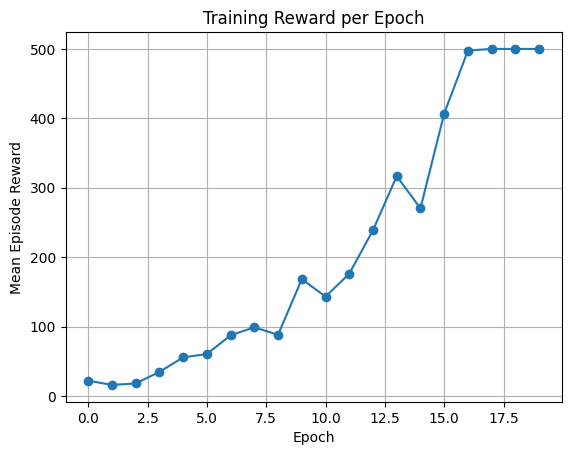

In [5]:
# Plot training rewards after training
import matplotlib.pyplot as plt
plt.plot(train_rewards, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Mean Episode Reward')
plt.title('Training Reward per Epoch')
plt.grid(True)
plt.show()


In [6]:
# Optionally, visualize one episode
obs, info = env.reset()
done = False
while not done:
    obs_t = torch.as_tensor(obs, dtype=torch.float32)
    logits = policy(obs_t)
    dist = Categorical(logits=logits)
    action = dist.probs.argmax().item()
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    env.render()
env.close()

/home/tsilva/miniconda3/envs/aiml-notebooks/lib/python3.11/site-packages/gymnasium/envs/classic_control/cartpole.py:250: UserWarning: WARN: You are calling render method without specifying any render mode. You can specify the render_mode at initialization, e.g. gym.make("CartPole-v1", render_mode="rgb_array")
  gym.logger.warn(


In [ ]:
# Evaluate the trained agent (confirmation)
mean_eval_reward, eval_rewards = evaluate_policy(policy, env, n_episodes=20)
for i, r in enumerate(eval_rewards):
    print(f"Episode {i+1}: Reward = {r}")
print(f"Mean reward over 20 episodes: {mean_eval_reward:.2f}")
if mean_eval_reward >= 475:
    print("CartPole-v1 solved!")
else:
    print("CartPole-v1 not solved. Try training for more epochs.")

Episode 1: Reward = 500.0
Episode 2: Reward = 500.0
Episode 3: Reward = 500.0
Episode 4: Reward = 500.0
Episode 5: Reward = 500.0
Episode 6: Reward = 500.0
Episode 7: Reward = 500.0
Episode 8: Reward = 500.0
Episode 9: Reward = 500.0
Episode 10: Reward = 500.0
Episode 11: Reward = 500.0
Episode 12: Reward = 500.0
Episode 13: Reward = 500.0
Episode 14: Reward = 500.0
Episode 15: Reward = 500.0
Episode 16: Reward = 500.0
Episode 17: Reward = 500.0
Episode 18: Reward = 500.0
Episode 19: Reward = 500.0
Episode 20: Reward = 500.0
Mean reward over 20 episodes: 500.00
CartPole-v1 solved!
